# Neural machine translation: LSTM + attention

In this demo, improve our LSTM only English-French translation model by adding attention. While LSTM model worked, it had a fundamental limitation: the entire source sentence was compressed into a single fixed-length context vector. This creates a bottleneck where early words in long sentences get "forgotten."

In this demo, we add **attention** to solve this problem. Instead of using only the final encoder state, the decoder can now look back at all encoder hidden states and focus on the most relevant parts of the input at each decoding step.

### Key improvement over Lesson 41

| Lesson 41 (no attention) | Lesson 43 (with attention) |
|--------------------------|----------------------------|
| Decoder sees only final encoder state | Decoder attends to all encoder states |
| Fixed-length bottleneck | Dynamic context per output token |
| Struggles with long sentences | Handles long sentences better |

### References

The attention mechanism for neural machine translation was introduced in:

> Bahdanau, D., Cho, K., & Bengio, Y. (2015). **Neural machine translation by jointly learning to align and translate.** *Proceedings of the 3rd International Conference on Learning Representations (ICLR).* https://arxiv.org/abs/1409.0473

The scaled dot-product attention used in Transformers (and in Keras' `Attention` layer):

> Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). **Attention is all you need.** *Advances in Neural Information Processing Systems, 30.* https://arxiv.org/abs/1706.03762

The OPUS-100 dataset used in this activity:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## Notebook set-up

**Note**: This notebook uses a few dependencies that may not be commonly found in development environments (they are not included in the course deeplearning container) I think this should colver it:

`pip install sacrebleu sacremoses sentencepiece transformers`

### Imports

In [ ]:
# Suppress TensorFlow warnings and select GPU
import logging
import os

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '1' # Select GPU, 0 for GPU 1, etc.

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras model components
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Embedding, Bidirectional, Concatenate, Attention
)

### Configuration

In [ ]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Set event level output filter for TensorFlow
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

## 1. Prepare assets

Using the OPUS-100 English-French translation corpus from Hugging Face datasets with subword tokenization (SentencePiece). Subword tokenization is essential for NMT (Neural Machine Translation) because it:
- Keeps vocabulary manageable (~8K tokens vs 50K+ words)
- Handles rare/unseen words by breaking them into known subwords
- Shares subword units across related words (e.g., "play", "playing", "played")

### 1.1. Load tokenizer

In [3]:
# Load pre-trained subword tokenizer (SentencePiece)
# MarianTokenizer is specifically designed for the Helsinki-NLP translation models
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

print(f'Tokenizer vocabulary size: {tokenizer.vocab_size}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

# Example of subword tokenization
example = 'The neural network learned representations'
tokens = tokenizer.tokenize(example)
print(f'\nExample tokenization:')
print(f'  Input: "{example}"')
print(f'  Tokens: {tokens}')

Tokenizer vocabulary size: 59514
Special tokens: {'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}

Example tokenization:
  Input: "The neural network learned representations"
  Tokens: ['▁The', '▁ne', 'ural', '▁network', '▁learned', '▁representations']


### 1.2. Load dataset

In [4]:
# Load OPUS-100 English-French translation dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr')

# Extract translation pairs and filter by token length
pairs = []
MAX_SEQ_LENGTH = 20  # Maximum tokens per sentence

for item in dataset['train']:

    en_text = item['translation']['en'].strip()
    fr_text = item['translation']['fr'].strip()
    
    # Check token length using tokenize() to avoid truncation warnings
    en_tokens = tokenizer.tokenize(en_text)
    fr_tokens = tokenizer.tokenize(fr_text)
    
    if len(en_tokens) <= MAX_SEQ_LENGTH and len(fr_tokens) <= MAX_SEQ_LENGTH:
        pairs.append((en_text, fr_text))
    
    # Limit dataset size for reasonable training time
    if len(pairs) >= 100000:
        break

print(f'Loaded {len(pairs)} translation pairs')
print(f'\nSample pairs:')

for en, fr in pairs[1:5]:
    print()
    print(f'  EN: {en}')
    print(f'  FR: {fr}')

Loaded 100000 translation pairs

Sample pairs:

  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.

  EN: Did you find something?
  FR: Par ici !

  EN: Article 6
  FR: Article 6


In [5]:
# Tokenize all pairs using the subword tokenizer
# The tokenizer handles both English and French (it's a multilingual SentencePiece model)
MAX_ENCODER_LEN = 22  # Slightly larger than MAX_SEQ_LENGTH for special tokens
MAX_DECODER_LEN = 24

# Tokenize source (English) sentences
encoder_inputs = tokenizer(
    [pair[0] for pair in pairs],
    padding='max_length',
    truncation=True,
    max_length=MAX_ENCODER_LEN,
    return_tensors='np'
)

# Tokenize target (French) sentences
decoder_input_texts = [pair[1] for pair in pairs]

decoder_inputs = tokenizer(
    decoder_input_texts,
    padding='max_length',
    truncation=True,
    max_length=MAX_DECODER_LEN - 1,  # Leave room for BOS token
    return_tensors='np'
)

# Prepare encoder data
encoder_input_data = encoder_inputs['input_ids']

# CRITICAL: Decoder input must start with BOS token (we use pad_token_id)
# This aligns training with inference, where we also start with pad_token_id
# decoder_input: [BOS, tok1, tok2, ..., tokN, pad, pad...]
# decoder_target: [tok1, tok2, ..., tokN, EOS, pad, pad...]
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_input_data[:, 1:1 + raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Targets are the original tokens (what we want to predict after BOS)
decoder_target_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_target_data[:, :raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Model dimensions
num_samples = len(pairs)
num_tokens = tokenizer.vocab_size  # Same vocab for encoder and decoder
max_encoder_len = MAX_ENCODER_LEN
max_decoder_len = MAX_DECODER_LEN

print(f'Vocabulary size: {num_tokens}')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'Training samples: {num_samples}')
print(f'\nEncoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')

# Verify alignment: at position 0, input is BOS (pad), target is first real token
print(f'\nVerifying BOS alignment:')
print(f'  Decoder input[0, :5]:  {decoder_input_data[0, :5]} (first should be {tokenizer.pad_token_id} = BOS)')
print(f'  Decoder target[0, :5]: {decoder_target_data[0, :5]} (first real token)')

Vocabulary size: 59514
Max encoder length: 22
Max decoder length: 24
Training samples: 100000

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)

Verifying BOS alignment:
  Decoder input[0, :5]:  [59513    35   195   453    32] (first should be 59513 = BOS)
  Decoder target[0, :5]: [  35  195  453   32 6987] (first real token)


## 2. Model definitions

This section defines all model components needed for training and evaluation. We build:
1. **Training model**: Encoder-decoder with attention mechanism
2. **Inference models**: Separate encoder and decoder for autoregressive translation
3. **Translation function**: Greedy decoding loop for generating translations
4. **BLEU callback**: Monitors translation quality during training

**Training architecture with attention:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
         │                                                       │
         ▼                                                       ▼
   ┌─────────────┐                                        ┌─────────────┐
   │  Embedding  │                                        │  Embedding  │
   └──────┬──────┘                                        └──────┬──────┘
          │                                                      │
          ▼                                                      ▼
  ┌───────────────┐       Initial states [h, c]           ┌─────────────┐
  │ Bidirectional │ ────────────────────────────────────► │    LSTM     │
  │     LSTM      │                                       └──────┬──────┘
  └───────┬───────┘                                              │
          │                                                      ▼
          │              ┌─────────────────────────────────────────────────┐
          │              │              ATTENTION LAYER                    │
          │              │                                                 │
          │              │  Query: decoder hidden states                   │
          │              │  Key/Value: encoder outputs (all timesteps)     │
          │              │                                                 │
   Encoder outputs       │  For each decoder position:                     │
   (all timesteps) ─────►│    1. Compute attention weights over encoder    │
          │              │    2. Create weighted sum (context vector)      │
          │              │    3. Concatenate context + decoder output      │
          │              └──────────────────────┬──────────────────────────┘
          │                                     │
          │                                     ▼
          │                              ┌─────────────┐
          │                              │    Dense    │
          │                              │  (softmax)  │
          │                              └──────┬──────┘
          │                                     │
          │                                     ▼
          │                               Output sequence
          │                                     │
          │                        ┌────────────┴────────────┐
          │                        ▼                         ▼
          │             Labels (shifted target)         Predictions
          │              "Bonjour monde </s>"       "Bonjour monde </s>"
          │                        │                         │
          │                        └─────────► Loss ◄────────┘
```

The key difference from Lesson 41: instead of just passing the final encoder state, we now pass **all encoder outputs** to an attention layer. At each decoder timestep, attention computes which encoder positions are most relevant for predicting the current output token.

### 2.1. Training model

The training model uses teacher forcing with attention. At each decoder step:
1. The decoder LSTM processes the (ground truth) previous token
2. The attention layer computes weights over all encoder outputs
3. A context vector (weighted sum of encoder outputs) is created
4. The context is concatenated with the decoder output and fed to Dense

In [6]:
def build_attention_model(latent_dim=256):
    '''Build encoder-decoder with Bahdanau-style attention.'''

    # ── Encoder ──────────────────────────────────────────────
    encoder_inputs = Input(shape=(max_encoder_len,), name='encoder_input')
    encoder_embedding = Embedding(num_tokens, latent_dim, mask_zero=True, name='encoder_embedding')
    encoder_embedded = encoder_embedding(encoder_inputs)
    
    # Bidirectional LSTM encoder - now we need return_sequences=True for attention
    encoder_lstm = Bidirectional(
        LSTM(latent_dim, return_sequences=True, return_state=True, name='encoder_lstm'),
        name='bidirectional_encoder'
    )
    
    # Get outputs (all timesteps) and states
    encoder_outputs, fwd_h, fwd_c, bwd_h, bwd_c = encoder_lstm(encoder_embedded)
    
    # Concatenate forward and backward states for decoder initialization
    state_h = Concatenate(name='concat_h')([fwd_h, bwd_h])
    state_c = Concatenate(name='concat_c')([fwd_c, bwd_c])
    encoder_states = [state_h, state_c]
    
    # ── Decoder ──────────────────────────────────────────────
    decoder_inputs = Input(shape=(max_decoder_len,), name='decoder_input')
    decoder_embedding = Embedding(num_tokens, latent_dim, mask_zero=True, name='decoder_embedding')
    decoder_embedded = decoder_embedding(decoder_inputs)
    
    # Decoder LSTM (latent_dim * 2 because bidirectional encoder)
    decoder_lstm = LSTM(latent_dim * 2, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_embedded, initial_state=encoder_states)
    
    # ── Attention ────────────────────────────────────────────
    # Keras Attention layer implements Luong-style (dot-product) attention
    # Query: decoder outputs, Key/Value: encoder outputs
    attention_layer = Attention(name='attention')
    context = attention_layer([decoder_outputs, encoder_outputs])
    
    # Concatenate attention context with decoder outputs
    decoder_combined = Concatenate(name='concat_attention')([context, decoder_outputs])
    
    # Output layer
    decoder_dense = Dense(num_tokens, activation='softmax', name='output')
    decoder_outputs = decoder_dense(decoder_combined)
    
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

### 2.2. Inference models

During inference, we generate translations one token at a time. With attention, the decoder needs access to encoder outputs at every step (not just the initial states). We structure this as:
- **Encoder model**: Returns encoder outputs (all timesteps) AND initial states
- **Decoder model**: Takes single token, states, AND encoder outputs; computes attention each step

In [ ]:
def build_inference_models(model, latent_dim=256):
    '''Build separate encoder and decoder models for inference with attention.'''
    
    # ── Encoder inference model ────────────────────────────────────────────
    encoder_input_layer = model.get_layer('encoder_input').input
    encoder_embedding_layer = model.get_layer('encoder_embedding')
    bidirectional_layer = model.get_layer('bidirectional_encoder')
    concat_h = model.get_layer('concat_h')
    concat_c = model.get_layer('concat_c')

    # Reconstruct encoder
    encoder_embedded = encoder_embedding_layer(encoder_input_layer)
    encoder_outputs, fwd_h, fwd_c, bwd_h, bwd_c = bidirectional_layer(encoder_embedded)
    state_h = concat_h([fwd_h, bwd_h])
    state_c = concat_c([fwd_c, bwd_c])
    
    # Encoder model now returns encoder_outputs (for attention) AND initial states
    encoder_model = Model(encoder_input_layer, [encoder_outputs, state_h, state_c])

    # ── Decoder inference model ────────────────────────────────────────────
    # Inputs: single token, previous states, and encoder outputs for attention
    decoder_input_layer = Input(shape=(1,), name='decoder_inf_input')
    decoder_state_input_h = Input(shape=(latent_dim * 2,), name='decoder_state_h')
    decoder_state_input_c = Input(shape=(latent_dim * 2,), name='decoder_state_c')
    encoder_outputs_input = Input(shape=(max_encoder_len, latent_dim * 2), name='encoder_outputs_input')
    
    # Reuse trained layers
    decoder_embedding_layer = model.get_layer('decoder_embedding')
    decoder_lstm_layer = model.get_layer('decoder_lstm')
    attention_layer = model.get_layer('attention')
    concat_attention_layer = model.get_layer('concat_attention')
    decoder_dense_layer = model.get_layer('output')

    # Reconstruct decoder with attention
    decoder_embedded = decoder_embedding_layer(decoder_input_layer)
    decoder_outputs, state_h, state_c = decoder_lstm_layer(
        decoder_embedded, initial_state=[decoder_state_input_h, decoder_state_input_c]
    )
    
    # Apply attention using encoder outputs
    context = attention_layer([decoder_outputs, encoder_outputs_input])
    decoder_combined = concat_attention_layer([context, decoder_outputs])
    decoder_outputs = decoder_dense_layer(decoder_combined)

    # Decoder model: takes token + states + encoder_outputs, returns probs + new states
    decoder_model = Model(
        [decoder_input_layer, decoder_state_input_h, decoder_state_input_c, encoder_outputs_input],
        [decoder_outputs, state_h, state_c]
    )
    
    return encoder_model, decoder_model

### 2.3. Translation function

The translation function implements greedy decoding with attention. The key difference from Lesson 41: we pass encoder outputs to every decoder step so attention can compute relevant context.

In [8]:
def translate(input_text, encoder_model, decoder_model):
    '''Translate English text to French using greedy decoding with attention.'''
    
    # Tokenize and pad the input sentence
    input_tokens = tokenizer(
        input_text,
        padding='max_length',
        max_length=max_encoder_len,
        truncation=True,
        return_tensors='np'
    )['input_ids']
    
    # Encode: get encoder outputs (for attention) and initial states
    encoder_outputs, state_h, state_c = encoder_model.predict(input_tokens, verbose=0)
    states = [state_h, state_c]
    
    # Start with pad token (acts as BOS for this tokenizer)
    target_seq = np.array([[tokenizer.pad_token_id]])
    decoded_tokens = []

    # Autoregressive decoding loop
    for _ in range(max_decoder_len):

        # Get next token probabilities and updated states
        # Note: encoder_outputs is passed every step for attention
        output_tokens, h, c = decoder_model.predict(
            [target_seq, states[0], states[1], encoder_outputs], verbose=0
        )
        
        # Greedy selection: pick highest probability token
        sampled_token_id = np.argmax(output_tokens[0, -1, :])
        
        # Stop if end-of-sequence token
        if sampled_token_id == tokenizer.eos_token_id:
            break
            
        # Append token and prepare for next iteration
        decoded_tokens.append(sampled_token_id)
        target_seq = np.array([[sampled_token_id]])
        states = [h, c]
    
    # Decode token IDs back to text
    return tokenizer.decode(decoded_tokens, skip_special_tokens=True)

### 2.4. BLEU score callback

The BLEU (Bilingual Evaluation Understudy) score measures translation quality by comparing n-gram overlap between the model's output and reference translations. Since BLEU requires actual translations, the callback must:
1. **Build inference models** from the current training model weights at each epoch
2. **Generate translations** using the translation function's autoregressive decoding
3. **Compute BLEU** on a sample of the training pairs

The callback implements **model checkpointing** based on BLEU score, saving the weights whenever BLEU improves and restoring them at the end of training. This ensures we keep the best-translating model even if the model overfits in later epochs (which we expect to see in the learning curves).

In [9]:
class BLEUCallback(tf.keras.callbacks.Callback):
    '''Callback to compute BLEU score and checkpoint best model.'''
    
    def __init__(self, pairs, sample_size=100, latent_dim=256, restore_best_weights=True):

        super().__init__()
        self.pairs = pairs
        self.sample_size = min(sample_size, len(pairs))
        self.latent_dim = latent_dim
        self.restore_best_weights = restore_best_weights
        
        # Track BLEU scores and best model weights
        self.bleu_scores = []
        self.bleu = BLEU()
        self.best_bleu = 0.0
        self.best_weights = None
        self.best_epoch = 0
        
        # Fixed sample for consistent evaluation across epochs
        np.random.seed(315)
        self.sample_indices = np.random.choice(len(pairs), size=self.sample_size, replace=False)
        
    def on_epoch_end(self, epoch, logs=None):

        # Build inference models to generate translations with current weights
        encoder_model, decoder_model = build_inference_models(self.model, self.latent_dim)
        
        # Translate sample sentences and collect references
        hypotheses = []
        references = []
        for idx in self.sample_indices:

            en_text, fr_ref = self.pairs[idx]
            fr_hyp = translate(en_text, encoder_model, decoder_model)
            hypotheses.append(fr_hyp)
            references.append(fr_ref)
        
        # Compute corpus BLEU
        result = self.bleu.corpus_score(hypotheses, [references])
        score = result.score
        self.bleu_scores.append(score)
        
        # Checkpoint if this is the best BLEU score so far
        if score > self.best_bleu:

            self.best_bleu = score
            self.best_weights = self.model.get_weights()
            self.best_epoch = epoch
            print(f' - BLEU: {score:.2f} (best)')

        else:
            print(f' - BLEU: {score:.2f} (best: {self.best_bleu:.2f})')
    
    def on_train_end(self, logs=None):

        # Restore best weights after training completes
        if self.restore_best_weights and self.best_weights is not None:

            print(f'Restoring best model weights from epoch {self.best_epoch + 1} (BLEU: {self.best_bleu:.2f})')
            self.model.set_weights(self.best_weights)

bleu_callback = BLEUCallback(pairs, sample_size=100, latent_dim=256, restore_best_weights=True)

## 3. Model training

### 3.1. Build

In [10]:
model = build_attention_model(latent_dim=256)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 22)]                 0         []                            
                                                                                                  
 encoder_embedding (Embeddi  (None, 22, 256)              1523558   ['encoder_input[0][0]']       
 ng)                                                      4                                       
                                                                                                  
 decoder_input (InputLayer)  [(None, 24)]                 0         []                            
                                                                                                  
 bidirectional_encoder (Bid  [(None, 22, 512),            1050624   ['encoder_embedding[0][0]'

### 3.2. Train

In [11]:
%%time

# Train the model (BLEUCallback handles checkpointing and early stopping)
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=32,
    epochs=15,
    validation_split=0.1,
    verbose=1,
    callbacks=[bleu_callback]
)

print(f'\nFinal training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'Best BLEU score: {bleu_callback.best_bleu:.2f}\n')

Epoch 1/15


W0000 00:00:1772596291.540159 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90100" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 4144693248 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
I0000 00:00:1772596295.441970 3130477 service.cc:145] XLA service 0x7a87cc531450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772596295.442024 3130477 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
I0000 00:00:1772596295.588724 3

2813/2813 [==============================] - ETA: 0s - loss: 2.1326 - accuracy: 0.6630

W0000 00:00:1772597426.495357 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90100" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 4144693248 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
W0000 00:00:1772597494.013351 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment 

 - BLEU: 4.40 (best)
2813/2813 [==============================] - 1457s 499ms/step - loss: 2.1326 - accuracy: 0.6630 - val_loss: 1.6060 - val_accuracy: 0.7252
Epoch 2/15
2813/2813 [==============================] - ETA: 0s - loss: 1.3954 - accuracy: 0.7488

...

 - BLEU: 48.50 (best: 50.55)
2813/2813 [==============================] - 1040s 370ms/step - loss: 0.2317 - accuracy: 0.9390 - val_loss: 1.6149 - val_accuracy: 0.7760
Epoch 14/15
2813/2813 [==============================] - ETA: 0s - loss: 0.2099 - accuracy: 0.9438

W0000 00:00:1772612806.905957 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90100" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 4144693248 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


 - BLEU: 57.14 (best)
2813/2813 [==============================] - 995s 354ms/step - loss: 0.2099 - accuracy: 0.9438 - val_loss: 1.6559 - val_accuracy: 0.7760
Epoch 15/15
2813/2813 [==============================] - ETA: 0s - loss: 0.1914 - accuracy: 0.9483

W0000 00:00:1772613868.819560 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90100" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 4144693248 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


 - BLEU: 59.91 (best)
2813/2813 [==============================] - 1060s 377ms/step - loss: 0.1914 - accuracy: 0.9483 - val_loss: 1.7023 - val_accuracy: 0.7746
Restoring best model weights from epoch 15 (BLEU: 59.91)

Final training loss: 0.1914
Final validation loss: 1.7023
Best BLEU score: 59.91

CPU times: user 5h 42min 23s, sys: 33min 25s, total: 6h 15min 48s
Wall time: 4h 56min 36s


### 3.3. Learning curves

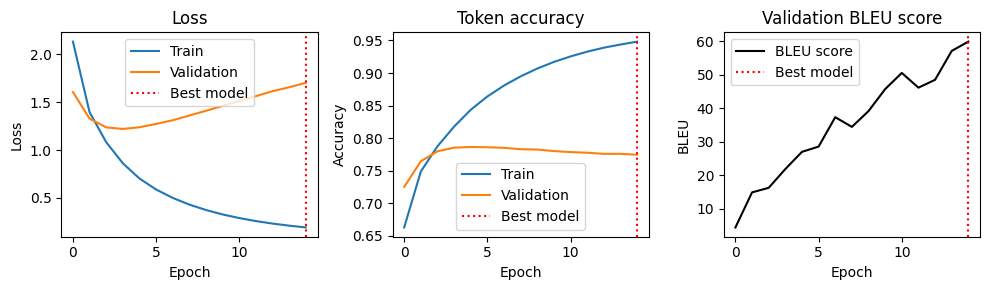

In [12]:
# Plot learning curves: loss, accuracy, and BLEU
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Epoch where best BLEU was achieved (model weights restored from here)
best_epoch = bleu_callback.best_epoch

# Left plot: training vs validation loss
# Overfitting visible when validation loss increases while training loss decreases
axes[0].set_title('Loss')
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')

# Middle plot: token-level accuracy
# Shows fraction of correctly predicted tokens (inflated by padding tokens)
axes[1].set_title('Token accuracy')
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

# Right plot: BLEU score over training
# Marker shows best checkpoint (weights restored from this epoch)
axes[2].set_title('Validation BLEU score')
axes[2].plot(bleu_callback.bleu_scores, c='black', label='BLEU score')
axes[2].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

**Note:** The loss and accuracy curves show clear overfitting (validation plateaus while training improves), yet BLEU continues to increase. Why?

- **Loss/accuracy** are computed using **teacher forcing** - the model sees ground truth previous tokens
- **BLEU** evaluates **autoregressive generation** - the model sees its own predictions

These are fundamentally different tasks. A model can memorize training sequences (overfitting the teacher-forcing objective) while its ability to generate coherent translations continues improving as embeddings become richer and general translation patterns solidify.

## 4. Translation examples and detailed evaluation

For inference, we split the model into separate encoder and decoder models. Unlike Lesson 41, the encoder now returns all hidden states (not just the final one), and the decoder uses attention to focus on relevant encoder positions at each step.

**Inference architecture with attention:**

```text

  STEP 1: Encode (run once)                     STEP 2: Decode token by token

  Input: "Hello world"                                 ┌─────────────┐
          │                           t=0: <pad> ─────►│  Embedding  │
          ▼                                            └──────┬──────┘
   ┌─────────────┐                                            │
   │  Embedding  │                                            ▼
   └──────┬──────┘                                     ┌─────────────┐
          │                           [h₀,c₀] ────────►│    LSTM     │───► [h₁,c₁]
          ▼                                            └──────┬──────┘
  ┌───────────────┐                                           │
  │ Bidirectional │                                           ▼
  │     LSTM      │    encoder_outputs ───────────────► ┌───────────┐
  └───────┬───────┘    (all timesteps)                  │ Attention │
          │                                             └─────┬─────┘
          ▼                                                   │
   [h₀,c₀] + encoder_outputs                                  ▼
                                                       ┌─────────────┐
                                                       │   Dense     │───► "Bonjour"
                                                       └─────────────┘

  t=0: <pad>     ──► LSTM ──► Attention(enc_out) ──► Dense ──► "Bonjour"
  t=1: "Bonjour" ──► LSTM ──► Attention(enc_out) ──► Dense ──► "monde"
  t=2: "monde"   ──► LSTM ──► Attention(enc_out) ──► Dense ──► </s>
```

At each step, attention computes weights over encoder outputs and creates a context vector that helps the decoder focus on the relevant source words.

In [13]:
# Build final inference models for translation examples
encoder_model, decoder_model = build_inference_models(model, latent_dim=256)

# Test translation on sample sentences
test_sentences = [
    'Hello, how are you?',
    'I love programming.',
    'The weather is nice today.'
]

print('Sample translations:')

for sent in test_sentences:

    print(f'  EN: {sent}')
    print(f'  FR: {translate(sent, encoder_model, decoder_model)}\n')

Sample translations:
  EN: Hello, how are you?


W0000 00:00:1772614054.074891 3130225 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce GTX 1070" frequency: 1683 num_cores: 15 environment { key: "architecture" value: "6.1" } environment { key: "cuda" value: "12050" } environment { key: "cudnn" value: "90100" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 2097152 shared_memory_size_per_multiprocessor: 98304 memory_size: 4144693248 bandwidth: 256256000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


  FR: Salut, comment ça va ?

  EN: I love programming.
  FR: Je me suis la promotion.

  EN: The weather is nice today.
  FR: Le temps est gentil aujourd'hui.



### 4.1. Evaluate translations

In [14]:
# Evaluate on a larger sample than used during training callback
np.random.seed(315)
sample_indices = np.random.choice(len(pairs), size=min(200, len(pairs)), replace=False)

# Collect model predictions and ground truth
hypotheses = []  # Model translations
references = []  # Ground truth translations

print('Generating translations for BLEU evaluation...')

for i, idx in enumerate(sample_indices):

    en_text, fr_ref = pairs[idx]
    fr_hyp = translate(en_text, encoder_model, decoder_model)
    
    hypotheses.append(fr_hyp)
    references.append(fr_ref)
    
    # Progress indicator
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(sample_indices)} samples')

# Compute corpus-level BLEU (aggregates n-gram precision across all sentences)
bleu = BLEU()
result = bleu.corpus_score(hypotheses, [references])

print(f'\nBLEU score: {result.score:.2f}')
print(f'Breakdown: {result}')

# Qualitative analysis: inspect individual translations
print('\nSample predictions vs references:')
for i in range(5):

    print(f'  Source: {pairs[sample_indices[i]][0]}')
    print(f'  Reference: {references[i]}')
    print(f'  Hypothesis: {hypotheses[i]}\n')

Generating translations for BLEU evaluation...
  Processed 50/200 samples
  Processed 100/200 samples
  Processed 150/200 samples
  Processed 200/200 samples

BLEU score: 56.85
Breakdown: BLEU = 56.85 72.5/59.4/52.7/46.9 (BP = 0.995 ratio = 0.995 hyp_len = 1238 ref_len = 1244)

Sample predictions vs references:
  Source: - Your daughter.
  Reference: Votre fille.
  Hypothesis: Votre fille.

  Source: - I'm doing it for you!
  Reference: Il faut que tu en parles à tes parents.
  Hypothesis: - Je fais ce qu'il vous pour vous!

  Source: http://www.eclaireurs.org
  Reference: http://scouts.montigny.free.fr
  Hypothesis: http://scouts.montigny.free.fr

  Source: Are you deaf? !
  Reference: T'es sourde ?
  Hypothesis: T'es sourde ?

  Source: My poorfellow, it seems we aren't much different.
  Reference: Nous sommes logés à la même enseigne, mon vieux.
  Hypothesis: Demain enfense ne semble plus jamais grand-chose.

